# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Es la continuación de la Tarea 1, por lo que se utilizarán los mismos datos y se puede reutilizar cualquier parte del código de dicha tarea.

Puede copiar este notebook en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y las librerías Pandas y scikit-learn. Para esta tarea se recomienda consultar la sección [Extracting features from text files](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) de la documentación oficial de scikit-learn.

Recuerde que **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook.

In [47]:
from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...
from sklearn.ensemble import RandomForestClassifier

## Descarga del dataset
Se utilizan los mismos datos que en la Tarea 1. Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas.

In [2]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

# Parte 1: Dataset y representación numérica de texto

## 1. Preparación del dataset
Se utilizará un conjunto de datos reducido de los **tres medios de prensa con mayor cantidad de artículos**.
Se espera que utilice su propia versión de la función `clean_text()` de la Tarea 1.

Particione los datos para generar un conjunto de test del 30% del total, utilizando muestreo estratificado.

**Sugerencia**: utilice el parámetro `stratify` de la función `train_test_split` de scikit-learn y fije también el valor de `random_state` para obtener resultados reproducibles.

In [3]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # TODO: completar signos de puntuación faltantes
    for punc in ["[", "\n", ",", ":", "?", "(", ")", "!", ".", "'", "\"", "’", "‘", "/", "“", "”", "]", "-", "#", ";", "xa0", "\xa0", "\x7f"]:
        result = result.str.replace(punc, " ")

    result.fillna("", inplace=True)

    return result

/var/folders/q6/qkwpcsmn3rnggq6m7rkgth2h0000gn/T/ipykernel_3558/4009594215.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_3['CleanText'] = clean_text(df_top_3, 'article')


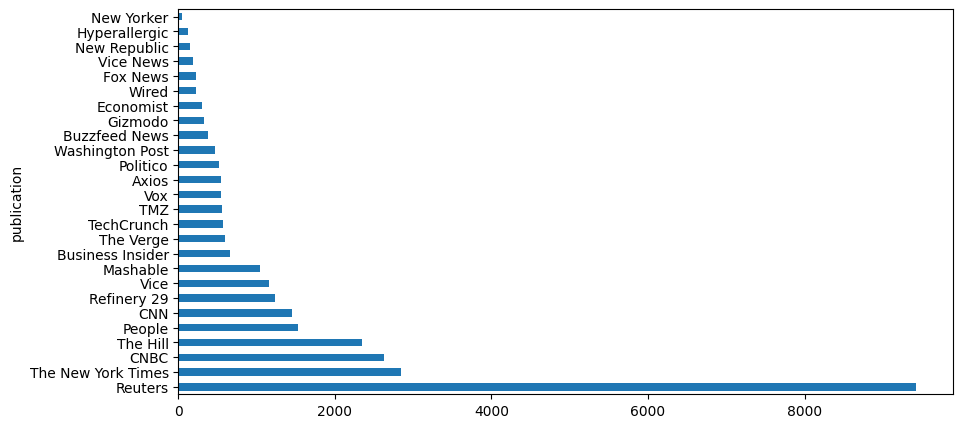

In [4]:
# TODO: Obtenga los tres medios con mayor cantidad de artículos y filtre el DataFrame
N = 3
count_by_publication = df['publication'].value_counts()
count_by_publication.plot(kind='barh', figsize=(10, 5))
top_3_publications = count_by_publication[:N].index.values
df_top_3 = df[df['publication'].isin(top_3_publications)]

# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"
df_top_3['CleanText'] = clean_text(df_top_3, 'article')

In [ ]:
# TODO: Particione los datos en train y test (30% test), con muestreo estratificado
X = df_top_3["CleanText"]
y = df_top_3["publication"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## 2. Verificación del balance de clases
Genere una visualización que permita verificar que el balance de artículos de cada medio es similar en train y test.

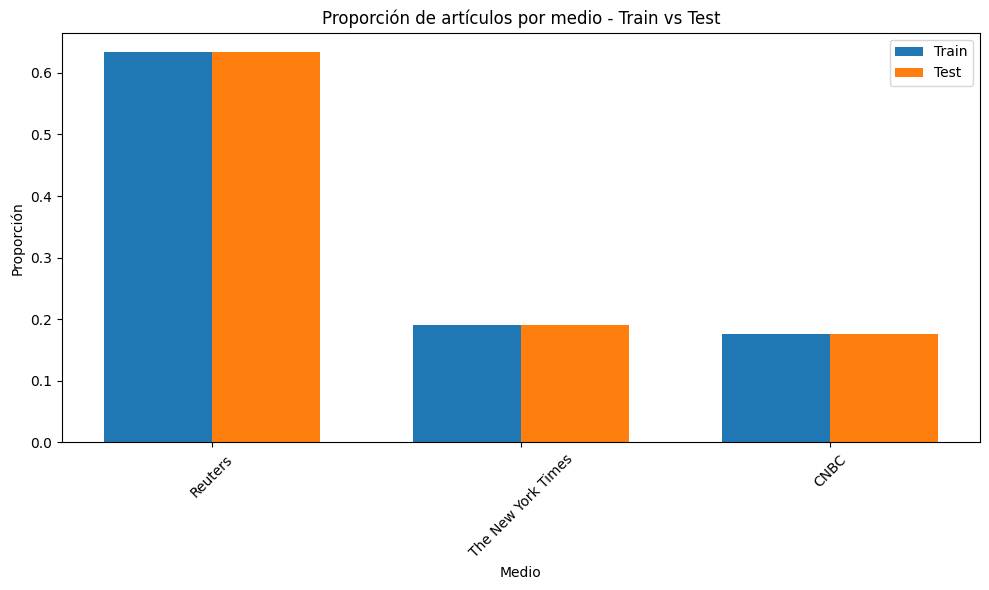

In [6]:
# TODO: Genere una visualización que muestre la proporción de artículos de cada medio
# en los conjuntos de train y test.
train_counts = y_train.value_counts(normalize=True)
test_counts = y_test.value_counts(normalize=True)

x = np.arange(len(top_3_publications))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_counts[top_3_publications].values, width, label='Train')
ax.bar(x + width/2, test_counts[top_3_publications].values, width, label='Test')
ax.set_title("Proporción de artículos por medio - Train vs Test")
ax.set_xlabel("Medio")
ax.set_ylabel("Proporción")
ax.set_xticks(x)
ax.set_xticklabels(top_3_publications, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## 3. Representación Bag of Words
Transforme el texto del conjunto de entrenamiento a una representación numérica (features) de conteo de palabras (*bag of words*).
Explique brevemente cómo funciona esta técnica y muestre un ejemplo.
En particular, explique el tamaño de la matriz resultante y la razón por la que es una matriz *sparse*.

**Sugerencia**: puede ser útil imaginar qué sucedería con la memoria RAM requerida si no estuviéramos trabajando con un conjunto de datos reducido.

In [7]:
# TODO: Transforme el texto de entrenamiento a una representación Bag of Words

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)

# Muestre el tamaño de la matriz resultante
print('Matrix shape:', X_train_bow.shape)

# Muestre un ejemplo: las primeras palabras del vocabulario y sus conteos en un documento
vocab = vectorizer.get_feature_names_out()
print('Vocabulary sample:', vocab[:10])
print('BoW vector for first document:', X_train_bow[0].toarray()[0][:10])



Matrix shape: (10425, 87044)
Vocabulary sample: ['00' '000' '0000' '00004' '000063' '0001' '000270' '000333' '0004' '0005']
BoW vector for first document: [0 0 0 0 0 0 0 0 0 0]


## 4. Representación TF-IDF
Explique brevemente qué es un **n-grama**.
Obtenga la representación numérica *Term Frequency - Inverse Document Frequency* (TF-IDF).
Explique brevemente en qué consiste esta transformación adicional.

In [8]:
# TODO: Obtenga la representación TF-IDF del conjunto de entrenamiento

# Muestre el tamaño de la matriz resultante
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
print('TF-IDF Matrix shape:', X_train_tfidf.shape)


TF-IDF Matrix shape: (10425, 87044)


## 5. Visualización PCA sobre TF-IDF
Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de TF-IDF.
Analice los resultados y compare qué sucede si utiliza:
- a) el filtrado de `stop_words` para idioma inglés;
- b) el parámetro `use_idf=True`;
- c) `ngram_range=(1,2)`.

Opcionalmente, también puede analizar qué sucede si no elimina los signos de puntuación.

¿Se pueden separar los medios de prensa utilizando sólo 2 componentes principales?
Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (por ejemplo, hasta 10 componentes).

Discuta además si la separación observada puede deberse a diferencias de estilo editorial, a diferencias temáticas o a pistas explícitas del medio que no hayan sido removidas en la limpieza.

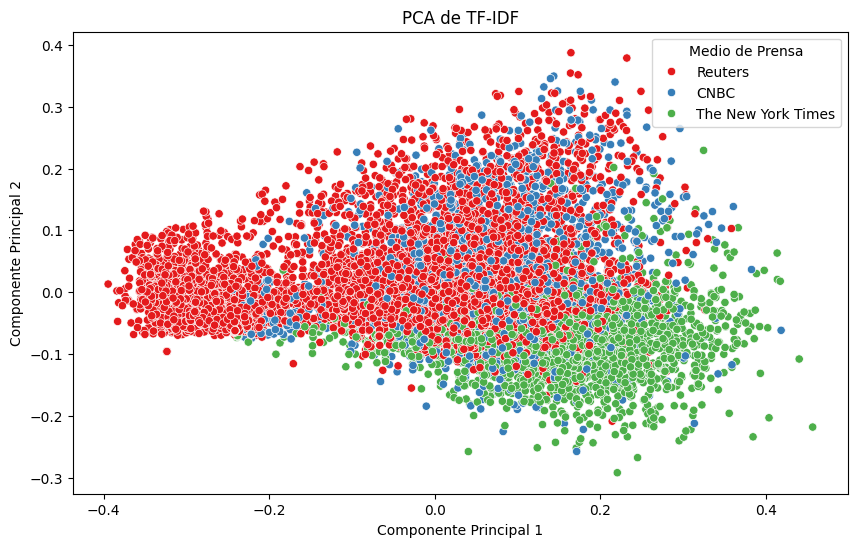

In [9]:
# TODO: Aplique PCA con 2 componentes sobre X_train_tfidf y grafique los resultados,
# coloreando los puntos según el medio de prensa.

def plot_pca(X, y, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1')
    plt.title(title)
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend(title='Medio de Prensa')
    plt.show()

plot_pca(X_train_tfidf, y_train, "PCA de TF-IDF")

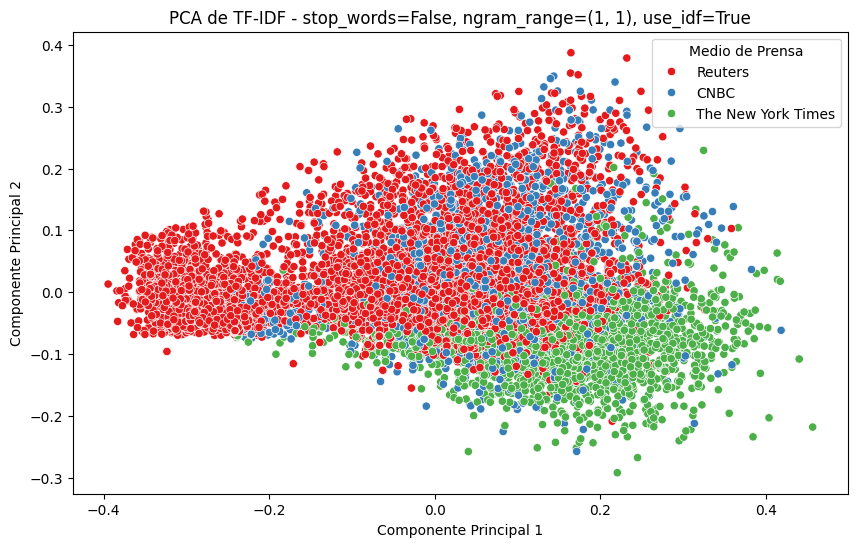

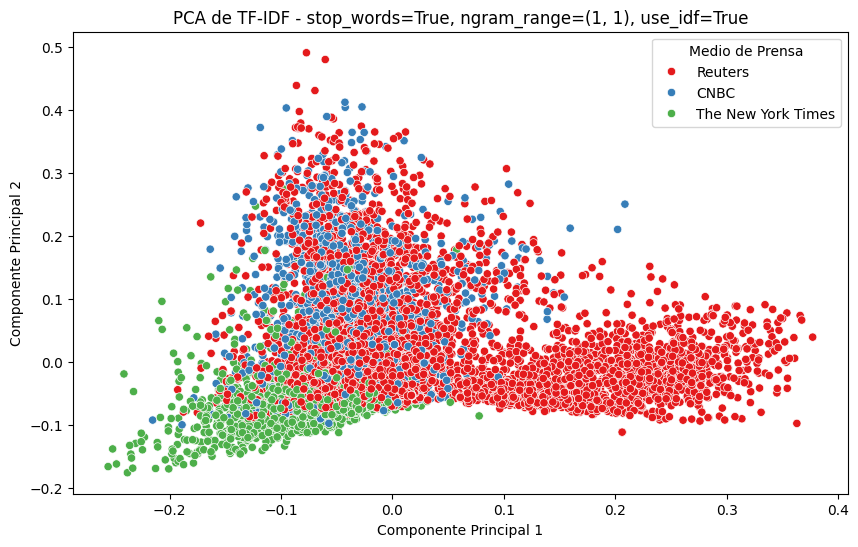

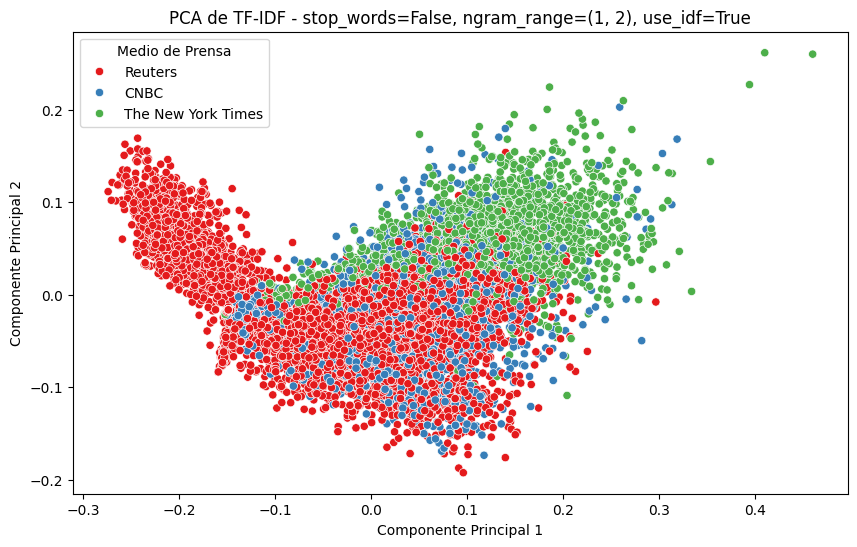

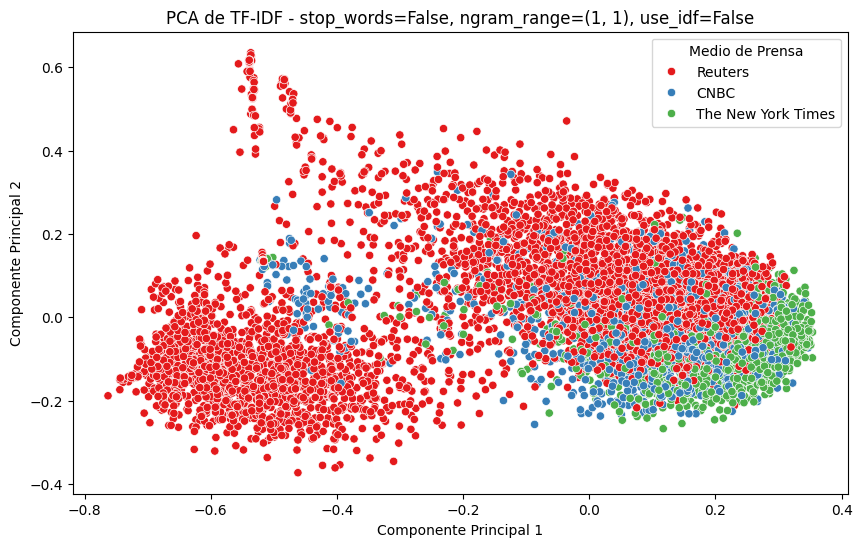

In [10]:
# TODO: Compare los resultados de PCA con distintas configuraciones del TfidfVectorizer:
def vectorize(X, filter_stop_words=False, ngram_range=(1, 1), use_idf=True):
    vectorizer = TfidfVectorizer(stop_words='english' if filter_stop_words else None, ngram_range=ngram_range, use_idf=use_idf)
    return vectorizer.fit_transform(X)

configurations = [
    {'filter_stop_words': False, 'ngram_range': (1, 1), 'use_idf': True},
    {'filter_stop_words': True, 'ngram_range': (1, 1), 'use_idf': True},
    {'filter_stop_words': False, 'ngram_range': (1, 2), 'use_idf': True},
    {'filter_stop_words': False, 'ngram_range': (1, 1), 'use_idf': False},
]
for config in configurations:
    X_tfidf = vectorize(X_train, **config)
    title = f"PCA de TF-IDF - stop_words={config['filter_stop_words']}, ngram_range={config['ngram_range']}, use_idf={config['use_idf']}"
    plot_pca(X_tfidf, y_train, title)
    

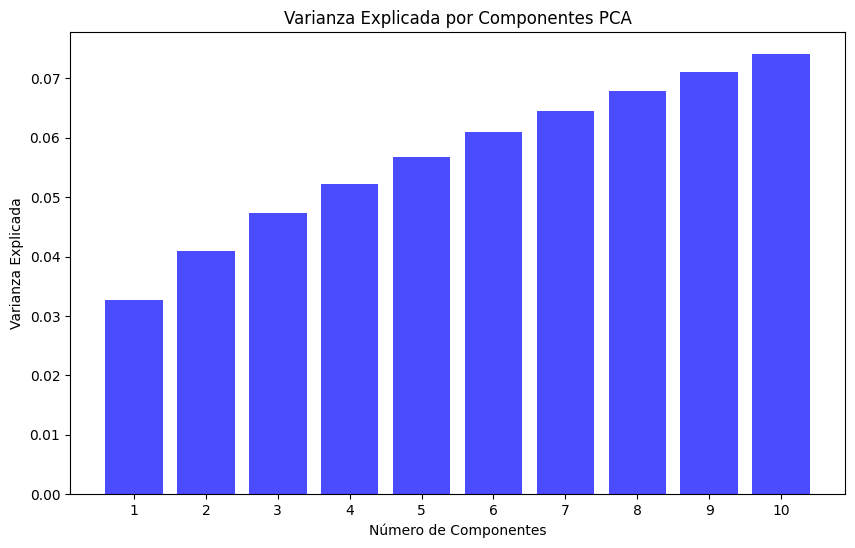

In [24]:
# TODO: Genere una visualización que muestre cómo varía la varianza explicada
# a medida que se agregan componentes PCA (por ejemplo, hasta 10 componentes).

pca = PCA(n_components=10)
pca.fit(X_train_tfidf)
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), np.cumsum(explained_variance), alpha=0.7, color='b')
plt.title("Varianza Explicada por Componentes PCA")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada")
plt.xticks(range(1, 11))
plt.show()


# Parte 2: Entrenamiento y Evaluación de Modelos

## 1. Multinomial Naive Bayes
Entrene el modelo *Multinomial Naive Bayes* para clasificar los artículos según a qué medio de prensa pertenece el texto.
Utilice dicho modelo para clasificar los artículos del conjunto de test, y reporte el valor de *accuracy* y la **matriz de confusión**.
Reporte además el valor de *precision* y *recall* para cada medio.
Explique cómo se relacionan estos valores con la matriz anterior.

¿Qué problemas puede tener el hecho de mirar solamente el valor de *accuracy*?
Considere qué sucedería con esta métrica si el desbalance de datos fuera aún mayor entre medios.

**Sugerencia**: utilice el método `from_predictions` de `ConfusionMatrixDisplay` para realizar la matriz.

In [29]:
# TODO: Entrene Multinomial Naive Bayes sobre X_train_tfidf
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Accuracy: 0.7418
Reporte para Reuters:
  Precision: 0.7672
  Recall: 0.9120
  F1-score: 0.8334
Reporte para The New York Times:
  Precision: 0.6422
  Recall: 0.7817
  F1-score: 0.7051
Reporte para CNBC:
  Precision: 1.0000
  Recall: 0.0864
  F1-score: 0.1591


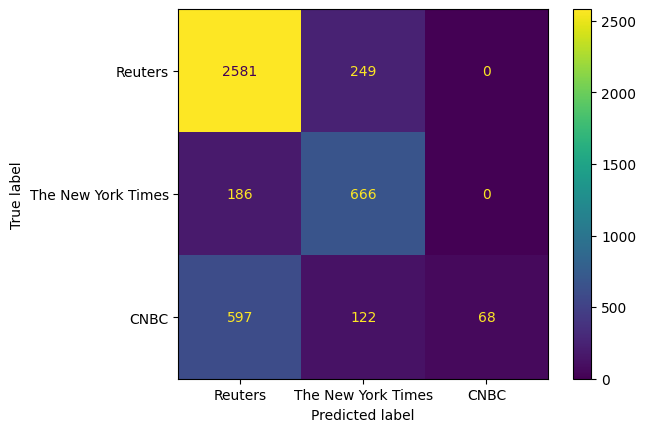

In [52]:
# TODO: Evalúe el modelo sobre el conjunto de test
X_test_tfidf = vectorizer_tfidf.transform(X_test)
y_test_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_test_pred, labels=top_3_publications)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=top_3_publications)
disp.plot()

report = classification_report(y_test, y_test_pred, labels=top_3_publications, target_names=top_3_publications, output_dict=True)
for publication in top_3_publications:
    print(f"Reporte para {publication}:")
    print(f"  Precision: {report[publication]['precision']:.4f}")
    print(f"  Recall: {report[publication]['recall']:.4f}")
    print(f"  F1-score: {report[publication]['f1-score']:.4f}")

## 2. Validación cruzada y búsqueda de hiperparámetros
Explique cómo funciona la técnica de **validación cruzada** (*cross-validation*).
Implemente una búsqueda de hiperparámetros usando `GridSearchCV`.
Genere una visualización que permita comparar las métricas (por ejemplo, *accuracy*) de los distintos modelos entrenados, viendo el valor promedio y la variabilidad de las mismas en todos los *splits* (por ejemplo, en un gráfico de violín).

In [31]:
# TODO: Defina la grilla de hiperparámetros y ejecute GridSearchCV
hyps = {
    'alpha': [0.1, 0.25, 0.5, 0.75, 1.0],
    'fit_prior': [True, False]
}

model = MultinomialNB()
grid_search = GridSearchCV(model, hyps, cv=5, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 0.25, ...], 'fit_prior': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

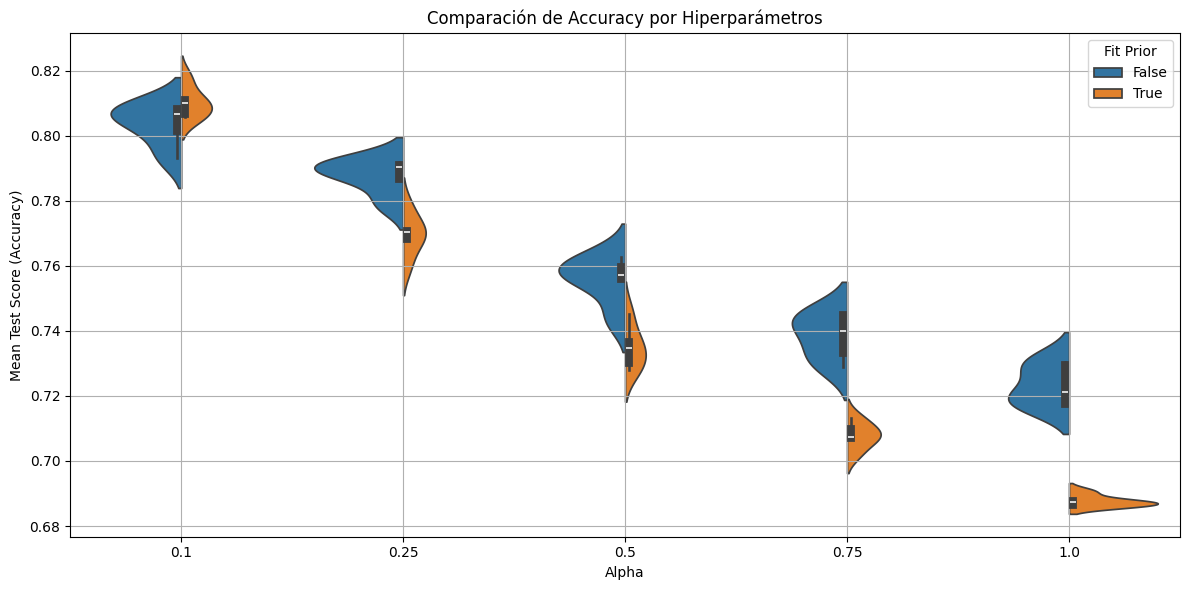

In [42]:
# TODO: Genere una visualización (por ejemplo, gráfico de violín) que compare
# la accuracy de los distintos modelos entrenados en GridSearchCV,
# mostrando la variabilidad en los distintos splits.
results_df = pd.DataFrame(grid_search.cv_results_)
param_cols = ["param_alpha", "param_fit_prior"]
score_cols = [f"split{i}_test_score" for i in range(5)]
results_df = results_df[param_cols + score_cols].set_index(param_cols)[score_cols].stack().reset_index(name='accuracy')
plt.figure(figsize=(12, 6))
# sns.violinplot(x='param_alpha', y='mean_test_score', hue='param_fit_prior', data=results_df, split=True)
sns.violinplot(
    data=results_df,
    x="param_alpha",
    y="accuracy",
    hue="param_fit_prior",
    split=True
)
plt.title("Comparación de Accuracy por Hiperparámetros")
plt.xlabel("Alpha")
plt.ylabel("Mean Test Score (Accuracy)")
plt.legend(title='Fit Prior')
plt.tight_layout()
plt.grid()
plt.show()

## 3. Entrenamiento final con el mejor modelo
Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación).
Reporte el valor final de las métricas y la matriz de confusión.
Discuta las limitaciones de utilizar un modelo basado en *bag of words* o TF-IDF para el análisis de texto.

In [44]:
# TODO: Entrene el mejor modelo sobre todo el conjunto de entrenamiento
best_params = grid_search.best_params_
best_model = MultinomialNB(**best_params)
best_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [53]:
# TODO: Evalúe el mejor modelo sobre el conjunto de test y reporte métricas finales

accuracy = accuracy_score(y_test, best_model.predict(X_test_tfidf))
print(f"Best Model Accuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, best_model.predict(X_test_tfidf), labels=top_3_publications)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=top_3_publications)
disp.plot()

report = classification_report(y_test, best_model.predict(X_test_tfidf), 
    labels=top_3_publications, target_names=top_3_publications, output_dict=True)
for publication in top_3_publications:
    print(f"Reporte para {publication}:")
    print(f"  Precision: {report[publication]['precision']:.4f}")
    print(f"  Recall: {report[publication]['recall']:.4f}")
    print(f"  F1-score: {report[publication]['f1-score']:.4f}")

ValueError: X has 16058 features, but MultinomialNB is expecting 87044 features as input.

## 4. Modelo alternativo
Evalúe al menos un modelo más (dentro de scikit-learn) aparte de *Multinomial Naive Bayes* para clasificar el texto utilizando las mismas *features* de texto.
Explique brevemente cómo funciona y compare los resultados con el anterior.

Random Forest Accuracy: 0.8311
Reporte para Reuters (Random Forest):
  Precision: 0.9575
  Recall: 0.3151
  F1-score: 0.4742
Reporte para The New York Times (Random Forest):
  Precision: 0.8174
  Recall: 0.9887
  F1-score: 0.8949
Reporte para CNBC (Random Forest):
  Precision: 0.8488
  Recall: 0.7840
  F1-score: 0.8151


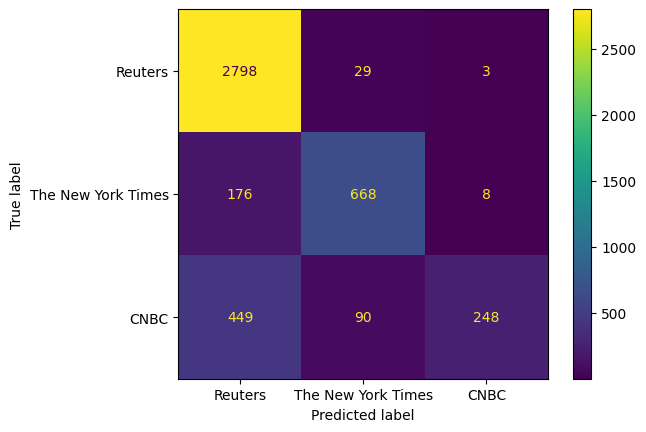

In [ ]:
# TODO: Entrene al menos un modelo alternativo de scikit-learn
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train_tfidf, y_train)

accuracy_rf = accuracy_score(y_test, random_forest.predict(X_test_tfidf))
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

conf_matrix_rf = confusion_matrix(y_test, random_forest.predict(X_test_tfidf), labels=top_3_publications)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=top_3_publications)
disp_rf.plot()

report_rf = classification_report(y_test, random_forest.predict(X_test_tfidf), 
    labels=top_3_publications, target_names=top_3_publications, output_dict=True)
for publication in top_3_publications:
    print(f"Reporte para {publication} (Random Forest):")
    print(f"  Precision: {report_rf[publication]['precision']:.4f}")
    print(f"  Recall: {report_rf[publication]['recall']:.4f}")
    print(f"  F1-score: {report_rf[publication]['f1-score']:.4f}")

## 5. Cambio de medio de prensa
Evalúe el problema cambiando al menos un medio de prensa.
En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
Puede ser útil comentar acerca de técnicas como sobre-muestreo y submuestreo; no es necesario implementarlas.

/var/folders/q6/qkwpcsmn3rnggq6m7rkgth2h0000gn/T/ipykernel_3558/2623162667.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sampled['CleanText'] = clean_text(df_sampled, 'article')


Accuracy con nuevo conjunto de medios: 0.8699
Reporte para The New York Times (nuevo conjunto):
  Precision: 0.8093
  Recall: 0.9366
  F1-score: 0.8683
Reporte para CNBC (nuevo conjunto):
  Precision: 0.9192
  Recall: 0.7230
  F1-score: 0.8094
Reporte para The Hill (nuevo conjunto):
  Precision: 0.9093
  Recall: 0.9532
  F1-score: 0.9307


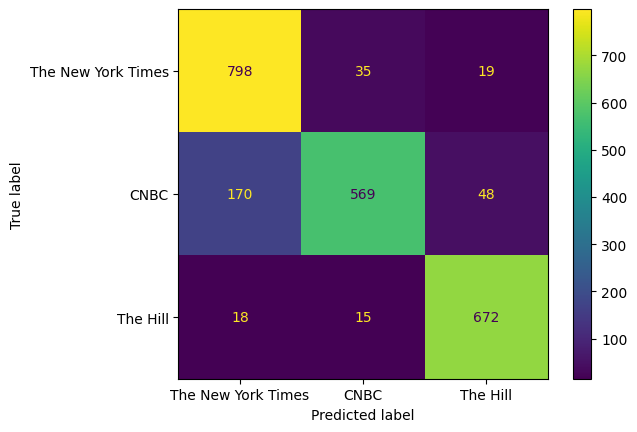

In [54]:
# TODO: Seleccione una combinación diferente de tres medios de prensa (cambiando al menos uno)
# y repita el proceso de entrenamiento y evaluación.

# Analice el balance de clases en este nuevo conjunto de datos
sampled_publications = count_by_publication[1:4].index.values
df_sampled = df[df['publication'].isin(sampled_publications)]

# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"
df_sampled['CleanText'] = clean_text(df_sampled, 'article')
X_train_sampled, X_test_sampled, y_train_sampled, y_test_sampled = train_test_split(
    df_sampled['CleanText'], df_sampled['publication'], test_size=0.3, random_state=42, stratify=df_sampled['publication']
)

model = MultinomialNB()
vectorizer_tfidf = TfidfVectorizer()
model.fit(vectorizer_tfidf.fit_transform(X_train_sampled), y_train_sampled)
accuracy_sampled = accuracy_score(y_test_sampled, model.predict(vectorizer_tfidf.transform(X_test_sampled)))
print(f"Accuracy con nuevo conjunto de medios: {accuracy_sampled:.4f}")

conf_matrix_sampled = confusion_matrix(y_test_sampled, model.predict(vectorizer_tfidf.transform(X_test_sampled)), labels=sampled_publications)
disp_sampled = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_sampled, display_labels=sampled_publications)
disp_sampled.plot()

report_sampled = classification_report(
    y_test_sampled, 
    model.predict(vectorizer_tfidf.transform(X_test_sampled)), 
    labels=sampled_publications, target_names=sampled_publications, output_dict=True)
for publication in sampled_publications:
    print(f"Reporte para {publication} (nuevo conjunto):")
    print(f"  Precision: {report_sampled[publication]['precision']:.4f}")
    print(f"  Recall: {report_sampled[publication]['recall']:.4f}")
    print(f"  F1-score: {report_sampled[publication]['f1-score']:.4f}")

## 6. Técnica alternativa de extracción de features
Busque información sobre al menos una técnica alternativa de extraer *features* de texto.
Explique brevemente cómo funciona y qué tipo de diferencias esperaría en los resultados.
No se espera que implemente nada en esta parte.

*TODO: Escriba su análisis en el informe.*

## 7. Opcional: Clasificación a nivel de título
Repita la clasificación con los tres medios de prensa originales, pero esta vez clasificando a nivel de **título** en lugar de artículo completo.

Accuracy usando título: 0.7004
Reporte para Reuters (usando título):
  Precision: 0.9559
  Recall: 0.0826
  F1-score: 0.1520
Reporte para The New York Times (usando título):
  Precision: 0.6843
  Recall: 0.9951
  F1-score: 0.8109
Reporte para CNBC (usando título):
  Precision: 0.8706
  Recall: 0.2923
  F1-score: 0.4376


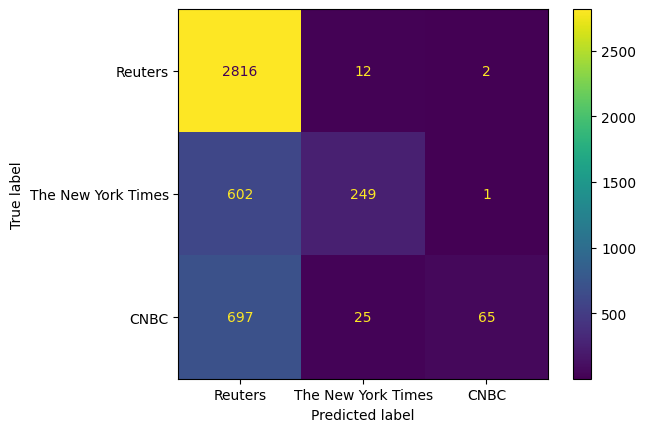

In [ ]:
# Opcional: Repita el pipeline de clasificación utilizando el título del artículo
# en lugar del cuerpo del texto.
X_title = clean_text(df_top_3, 'title')
X_train_title, X_test_title, y_train_title, y_test_title = train_test_split(X_title, y, test_size=0.3, random_state=42, stratify=y)

model = MultinomialNB()
vectorizer_tfidf = TfidfVectorizer()
model.fit(vectorizer_tfidf.fit_transform(X_train_title), y_train_title)
y_test_title_pred = model.predict(vectorizer_tfidf.transform(X_test_title))
accuracy_title = accuracy_score(y_test_title, y_test_title_pred)
print(f"Accuracy usando título: {accuracy_title:.4f}")

conf_matrix_title = confusion_matrix(y_test_title, y_test_title_pred, labels=top_3_publications)
disp_title = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_title, display_labels=top_3_publications)
disp_title.plot()

report_title = classification_report(y_test_title, y_test_title_pred, 
    labels=top_3_publications, target_names=top_3_publications, output_dict=True)
for publication in top_3_publications:
    print(f"Reporte para {publication} (usando título):")
    print(f"  Precision: {report_title[publication]['precision']:.4f}")
    print(f"  Recall: {report_title[publication]['recall']:.4f}")
    print(f"  F1-score: {report_title[publication]['f1-score']:.4f}")
    